In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#paso 3: leer el archivo
df =  pd.read_csv("abandono_once.csv")

#ver primera filas
df.head()

,OBJECTID,Dane,Departamento,Transicion,BasicaPrimaria,BasicaSecundaria,EducacionMedia,Hombre,Mujer,ShapeSTArea,ShapeSTLength
0,1,5,Antioquia,0.20,1.41,2.27,1.12,1.84,1.30,6.465952e+10,1.985193e+06
1,2,8,Atlántico,1.79,1.71,1.89,0.79,1.97,1.35,3.500917e+09,2.461099e+05
2,3,11,Bogotá D.C.,0.91,4.88,10.78,5.54,8.20,5.57,1.671309e+09,3.257371e+05
3,4,13,Bolívar,1.09,2.12,2.19,0.83,2.42,1.38,2.693296e+10,1.331045e+06
4,5,15,Boyacá,0.40,1.28,2.55,1.37,2.00,1.37,2.373782e+10,1.376617e+06


In [6]:
# limpieza y reparacion de datos

#verificacion de la información general
df.info()

#verificamos nulos
print(df.isnull().sum())

#buscamos valores duplicados
df.duplicated().sum()


#destadistica
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OBJECTID          33 non-null     int64  
 1   Dane              33 non-null     int64  
 2   Departamento      33 non-null     object 
 3   Transicion        33 non-null     float64
 4   BasicaPrimaria    33 non-null     float64
 5   BasicaSecundaria  33 non-null     float64
 6   EducacionMedia    33 non-null     float64
 7   Hombre            33 non-null     float64
 8   Mujer             33 non-null     float64
 9   ShapeSTArea       33 non-null     float64
 10  ShapeSTLength     33 non-null     float64
dtypes: float64(8), int64(2), object(1)
memory usage: 3.0+ KB
OBJECTID            0
Dane                0
Departamento        0
Transicion          0
BasicaPrimaria      0
BasicaSecundaria    0
EducacionMedia      0
Hombre              0
Mujer               0
ShapeSTArea         0
Shap

,OBJECTID,Dane,Transicion,BasicaPrimaria,BasicaSecundaria,EducacionMedia,Hombre,Mujer,ShapeSTArea,ShapeSTLength
count,33.00000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,3.300000e+01,3.300000e+01
mean,17.00000,52.151515,0.970303,1.671818,2.576970,1.379697,2.237879,1.555152,3.510245e+10,1.131315e+06
std,9.66954,31.268116,1.139110,1.114289,1.938602,1.072665,1.590395,1.099458,2.933080e+10,5.733334e+05
min,1.00000,5.000000,0.080000,0.160000,0.110000,0.060000,0.180000,0.110000,5.167584e+07,7.347028e+04
25%,9.00000,20.000000,0.310000,0.930000,1.670000,0.680000,1.400000,0.900000,2.199185e+10,8.493328e+05
50%,17.00000,52.000000,0.400000,1.280000,2.190000,1.120000,1.840000,1.300000,2.459937e+10,1.047677e+06
75%,25.00000,81.000000,1.220000,1.960000,2.860000,1.560000,2.440000,1.650000,4.756022e+10,1.559462e+06
max,33.00000,99.000000,5.100000,4.880000,10.780000,5.540000,8.200000,5.570000,1.106013e+11,2.570021e+06


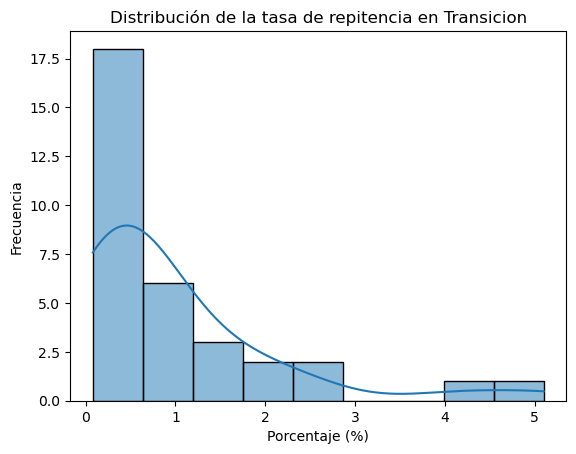

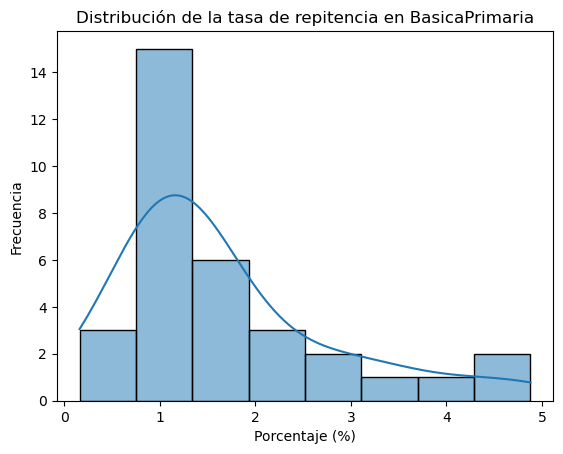

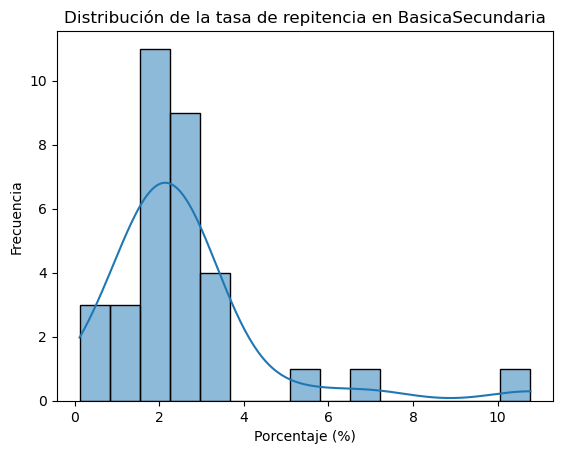

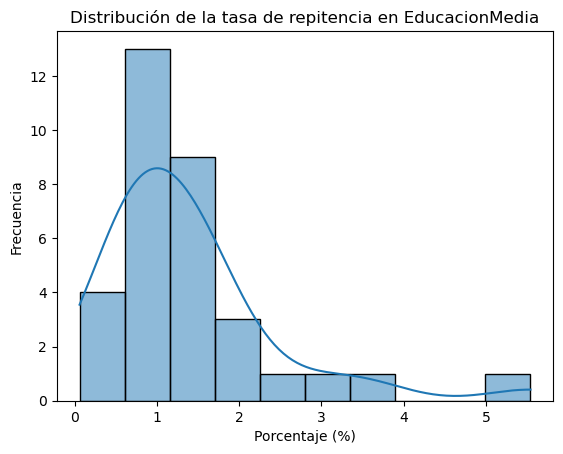

In [9]:
niveles = ["Transicion", "BasicaPrimaria", "BasicaSecundaria", "EducacionMedia"]

for nivel in niveles:
    sns.histplot(df[nivel], kde=True)
    plt.title(f"Distribución de la tasa de repitencia en {nivel}")
    plt.xlabel("Porcentaje (%)")
    plt.ylabel("Frecuencia")
    plt.show()

In [10]:
df.sort_values("BasicaSecundaria", ascending=False).head(10)

,OBJECTID,Dane,Departamento,Transicion,BasicaPrimaria,BasicaSecundaria,EducacionMedia,Hombre,Mujer,ShapeSTArea,ShapeSTLength
2,3,11,Bogotá D.C.,0.91,4.88,10.78,5.54,8.20,5.57,1.671309e+09,3.257371e+05
32,33,88,San Andrés y Providencia,4.12,3.31,6.98,3.63,6.02,3.42,5.167584e+07,7.347028e+04
27,28,91,Amazonas,2.46,4.41,5.16,2.58,4.93,3.63,1.106013e+11,2.570021e+06
24,25,81,Arauca,1.42,1.96,3.63,2.04,2.89,1.94,2.459937e+10,8.493328e+05
20,21,68,Santander,0.87,1.48,3.29,1.35,2.44,1.65,3.090348e+10,1.047677e+06
28,29,94,Guainía,5.10,3.72,3.06,1.55,3.59,3.60,7.212326e+10,1.882043e+06
30,31,97,Vaupés,0.76,2.96,3.01,3.20,3.23,2.44,5.325214e+10,1.668972e+06
10,11,25,Cundinamarca,0.38,1.39,2.95,1.52,2.30,1.49,2.311320e+10,1.172847e+06
9,10,23,Córdoba,2.32,2.85,2.86,1.73,3.35,1.98,2.574303e+10,8.252400e+05
5,6,17,Caldas,0.31,1.57,2.75,1.42,2.25,1.48,7.670593e+09,6.076933e+05


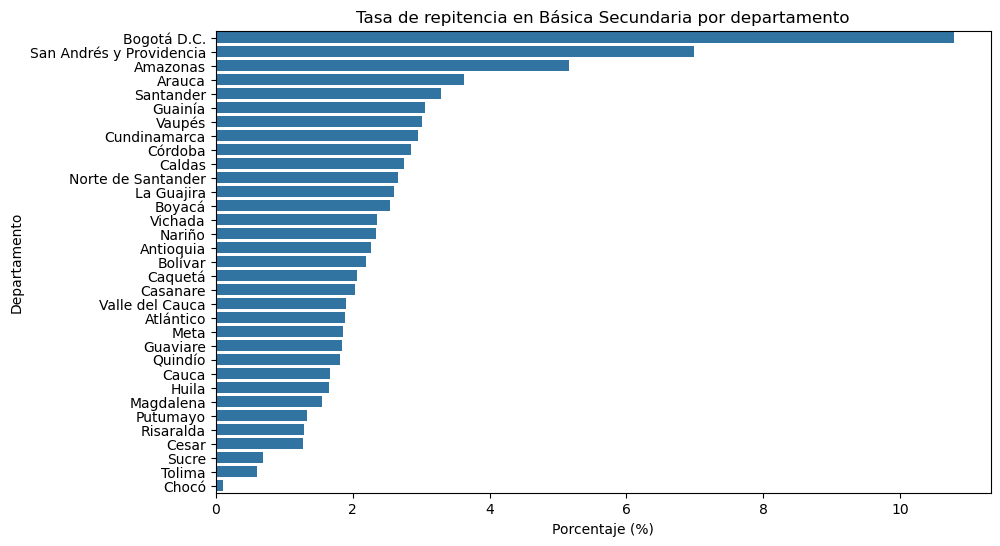

In [11]:
df_sorted = df.sort_values("BasicaSecundaria", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=df_sorted, x="BasicaSecundaria", y="Departamento")
plt.title("Tasa de repitencia en Básica Secundaria por departamento")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Departamento")
plt.show()